# Noise-Aware Training under Photonic Multiplication Error

This notebook evaluates whether noise-aware training improves network robustness beyond the
correction schemes evaluated in the inference experiments.

The experiment trains a CIFAR-100 ResNet18 from scratch for 12 epochs using three random
seeds. Four simulated noise levels are evaluated,
\(\sigma \in \{2.7588, 5.5, 11, 22\}\). Five numerical cases are included: the uncorrected
4-bit baseline, non-uniform slicing, parallel MSB-corner correction, low-bit congruent
correction and the failed low-bit splice rule as a control. The low-bit decomposed
implementation is not trained separately because it supplies the same residue to the same
congruent decoder and is numerically identical to the low-bit congruent case under the
ideal-table model.

Three measurements are used:

| Curve | Training | Evaluation | Purpose |
|---|---|---|---|
| A | clean | clean | clean reference |
| B | clean | noisy | effect of photonic error without retraining |
| C | noisy | noisy | effect after noise-aware training |

Comparing Curves B and C shows how much degradation is recovered by retraining. The completed
outputs retained in this notebook are the runs reported in the thesis.


## 0. Optional Cache Reset

The experiment checkpoints completed runs by configuration and seed. The reset cell below is
disabled by default so opening or rerunning the public notebook does not accidentally delete
completed local results. Enable it only when a completely fresh run is required.


In [ ]:
import os
import shutil

RESET_CACHED_RESULTS = False

if RESET_CACHED_RESULTS:
    for p in ["/content/results.json", "/content/clean_model.pt"]:
        if os.path.exists(p):
            os.remove(p)
            print(f"removed {p}")
        else:
            print(f"not present: {p}")
else:
    print("Cache reset disabled.")

# Mount Drive when running in Colab. A cached CIFAR-100 archive can be reused from Drive.
if os.path.isdir("/content"):
    try:
        if not os.path.isdir("/content/drive/MyDrive"):
            from google.colab import drive
            drive.mount("/content/drive")
    except ImportError:
        pass


## 1. Configuration

In [ ]:
# ============================================================
#                     CONFIGURATION
# ============================================================

QUICK_TEST = False        # True for a short pipeline smoke test.

# LightMat-HP 4-bit characterisation uses sigma = 2.7588.
# Larger values are synthetic stress-test points.
SIGMAS = [2.7588, 5.5, 11.0, 22.0]

SCHEMES = ["base", "nonuni", "parallel", "lowbit_cong", "lowbit_splice"]

N_SEEDS      = 3
EPOCHS       = 12
BATCH_SIZE   = 256
LR_MAX       = 0.2
LABEL_SMOOTH = 0.1
K_LOWBITS    = 4
NUM_WORKERS  = 2

N_CHARACTERISE = 40000
SEED = 42

TRAIN_SUBSET = None       # None uses all 50,000 CIFAR-100 training images.

if QUICK_TEST:
    EPOCHS = 1
    SIGMAS = [2.7588]
    SCHEMES = ["base", "parallel"]
    N_SEEDS = 1
    N_CHARACTERISE = 8000
    TRAIN_SUBSET = 10000

N_TRAIN_IMAGES = TRAIN_SUBSET if TRAIN_SUBSET else 50000

# Result keys include the main training configuration so cached values from a
# different run are not reused accidentally.
def cfg_tag():
    return f"e{EPOCHS}_n{N_TRAIN_IMAGES}_b{BATCH_SIZE}"

print("Configuration")
print(f"  Quick test    : {QUICK_TEST}")
print(f"  Sigmas        : {SIGMAS}")
print(f"  Schemes       : {SCHEMES}")
print(f"  Seeds         : {N_SEEDS}")
print(f"  Epochs        : {EPOCHS}")
print(f"  Train images  : {N_TRAIN_IMAGES:,}")
print(f"  Config tag    : {cfg_tag()}")

n_train_runs = len(SCHEMES) * len(SIGMAS) * N_SEEDS + N_SEEDS
n_infer = len(SCHEMES) * len(SIGMAS)
print(f"\n  Training runs : {len(SCHEMES)} schemes x {len(SIGMAS)} sigmas x {N_SEEDS} seeds"
      f" + {N_SEEDS} clean = {n_train_runs}")
print(f"  Curve B evals : {n_infer}")


In [ ]:
import os, json, time, math, sys
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision
from torchvision import transforms

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.benchmark = True

print("Environment")
print(f"  Python      : {sys.version.split()[0]}")
print(f"  NumPy       : {np.__version__}")
print(f"  PyTorch     : {torch.__version__}")
print(f"  torchvision : {torchvision.__version__}")
print(f"  Device      : {DEVICE}")
if DEVICE == "cuda":
    print(f"  GPU         : {torch.cuda.get_device_name(0)}")


## 2. Stage A: Multiplier Characterisation

For each scheme and noise level, Stage A runs 40,000 exact component-level simulations on
normalised mantissa pairs. FP16 uses the 12-bit nibble-aligned surrogate and FP32 uses
24 bits. The resulting relative-error mean and standard deviation are used by the
network-level model in Stage B.

Both precisions are characterised as a consistency check on the error model. The
noise-aware training experiment itself is performed at FP16 only. No FP32 network-training
result is inferred from the component-level agreement.

The original completed run used a scheme-specific seed offset derived from Python's built-in
`hash()` function. Python string hashes can vary between interpreter processes, so a fresh
process is not guaranteed to draw exactly the same 40,000 Stage A samples. The values stored
in this notebook are the characterisation values used for the reported training runs.


In [4]:
ERROR_PARAMS = {2: (0.0219, 0.1693), 3: (0.2144, 0.7048), 4: (0.2041, 2.7588)}
SIGMA_RATIO = {d: ERROR_PARAMS[d][1] / ERROR_PARAMS[4][1] for d in ERROR_PARAMS}
MU_RATIO    = {d: ERROR_PARAMS[d][0] / ERROR_PARAMS[4][0] for d in ERROR_PARAMS}
MANTISSA_BITS = {"FP16": 12, "FP32": 24}

LUT_2BIT = np.array([[x * y for y in range(4)] for x in range(4)], dtype=np.int64)

def residue_decomposed(a_nib, b_nib):
    """(a*b) mod 16 from three reads of the 16-entry 2-bit table.
    a*b = 16(a_hi b_hi) + 4(a_hi b_lo + a_lo b_hi) + a_lo b_lo; the first term vanishes
    mod 16, so a_hi*b_hi is never needed."""
    ah, al = a_nib >> 2, a_nib & 3
    bh, bl = b_nib >> 2, b_nib & 3
    return (4 * (LUT_2BIT[ah, bl] + LUT_2BIT[al, bh]) + LUT_2BIT[al, bl]) % 16

assert all(int(residue_decomposed(np.array([a]), np.array([b]))[0]) == (a * b) % 16
           for a in range(16) for b in range(16))
print("16-entry decomposition verified over all 256 nibble pairs.")


def characterise(scheme, precision, sigma, n=None, seed=0):
    """Exact per-multiplication simulation. Returns (mean rel err, std rel err)."""
    n = N_CHARACTERISE if n is None else n
    p = MANTISSA_BITS[precision]; nn_ = p // 4
    rg = np.random.default_rng(seed)
    mu = 0.2041 * (sigma / 2.7588)
    M = 2 ** K_LOWBITS

    A = rg.integers(2 ** (p - 1), 2 ** p, n)
    B = rg.integers(2 ** (p - 1), 2 ** p, n)
    true = np.array([float(int(x) * int(y)) for x, y in zip(A, B)])
    an = [(A >> (4 * i)) & 15 for i in range(nn_)]
    bn = [(B >> (4 * j)) & 15 for j in range(nn_)]
    tot = np.zeros(n)

    if scheme in ("base", "lowbit_cong", "lowbit_splice"):
        for i in range(nn_):
            for j in range(nn_):
                t = (an[i] * bn[j]).astype(float)
                z = t + mu + sigma * rg.normal(size=n)
                if scheme == "base":
                    pp = z
                else:
                    zz = z - mu
                    r = residue_decomposed(an[i], bn[j]).astype(float)
                    if scheme == "lowbit_splice":
                        c = np.rint(zz).astype(np.int64)
                        pp = (((c >> K_LOWBITS) << K_LOWBITS) | r.astype(np.int64)).astype(float)
                    else:
                        blk = np.floor((zz - r) / M)
                        cand = np.stack([(blk + o) * M + r for o in (-1, 0, 1)], axis=1)
                        pp = cand[np.arange(n), np.abs(cand - zz[:, None]).argmin(1)]
                tot += pp * (2.0 ** (4 * (i + j)))

    elif scheme == "parallel":
        for i in range(nn_):
            for j in range(nn_):
                if i == nn_ - 1 and j == nn_ - 1:
                    continue
                t = (an[i] * bn[j]).astype(float)
                tot += (t + mu + sigma * rg.normal(size=n)) * (2.0 ** (4 * (i + j)))
        al, ah = an[nn_-1] & 3, (an[nn_-1] >> 2) & 3
        bl, bh = bn[nn_-1] & 3, (bn[nn_-1] >> 2) & 3
        b0 = 4 * (2 * (nn_ - 1))
        for av, bv, sh in [(ah, bh, b0+4), (ah, bl, b0+2), (al, bh, b0+2), (al, bl, b0)]:
            tot += (av * bv).astype(float) * (2.0 ** sh)      # exact, 16-entry LUT

    elif scheme == "nonuni":
        subs = [(k, 4, 4 * k) for k in range(nn_ - 1)]
        subs += [("lo", 2, 4 * (nn_ - 1)), ("hi", 2, 4 * (nn_ - 1) + 2)]
        def val(nb, tg):
            if tg == "lo": return nb[nn_-1] & 3
            if tg == "hi": return (nb[nn_-1] >> 2) & 3
            return nb[tg]
        for (ta, wa, oa) in subs:
            for (tb, wb, ob) in subs:
                t = (val(an, ta) * val(bn, tb)).astype(float)
                if wa == 2 and wb == 2:
                    pp = t                                     # exact, 16-entry LUT
                else:
                    d = max(wa, wb)
                    pp = t + mu * MU_RATIO[d] + sigma * SIGMA_RATIO[d] * rg.normal(size=n)
                tot += pp * (2.0 ** (oa + ob))
    else:
        raise ValueError(scheme)

    rel = (tot - true) / true
    return float(rel.mean()), float(rel.std())


LABEL = {"base": "1. Baseline 4-bit",
         "nonuni": "2. Non-uniform slicing + LUT",
         "parallel": "3. Parallel non-uniform + LUT",
         "lowbit_cong": "4. Low-bit congruent",
         "lowbit_splice": "5. Low-bit splice (control)"}

ERR = {}
print(f"\nPer-multiplication relative error, N = {N_CHARACTERISE:,}")
print("=" * 100)
print(f"{'sigma':>8}  {'scheme':<32}{'FP16 mean':>12}{'FP16 std':>12}"
      f"{'FP32 mean':>12}{'FP32 std':>12}{'FP16 vs FP32':>14}")
print("-" * 100)
for sg in SIGMAS:
    for s in SCHEMES:
        # Historical thesis-run seed rule. Python hash randomisation means these exact
        # Stage A draws are process-dependent; see the reproducibility note above.
        scheme_seed = SEED + abs(hash(s)) % 997
        m16, s16 = characterise(s, "FP16", sg, seed=scheme_seed)
        m32, s32 = characterise(s, "FP32", sg, seed=scheme_seed)
        ERR[(sg, s)] = (m16, s16)
        agree = "same" if abs(s16 - s32) / max(s16, 1e-12) < 0.15 else "DIFFER"
        print(f"{sg:>8.4f}  {LABEL[s]:<32}{m16:>11.4%}{s16:>11.4%}"
              f"{m32:>11.4%}{s32:>11.4%}{agree:>14}")
    print("-" * 100)
print("=" * 100)
print("FP16 and FP32 relative-error spreads are similar across the evaluated cases.")
print("The network-level noise-aware training experiment is therefore restricted to FP16.")
print("No FP32 network-training result is claimed from this comparison.")
print()
print("The low-bit congruent and splice cases are heavy-tailed rather than Gaussian: they")
print("are often exact and occasionally move to a neighbouring residue block. Their standard")
print("deviations therefore require more samples to estimate stably than the smoother schemes.")
print()
print("Reproducibility note: the completed thesis run used Python hash(s) for the scheme-specific")
print("Stage A seed offset. Exact fresh-process sample draws can therefore differ unless the")
print("recorded characterisation values are reused or the seed mapping is fixed explicitly.")

16-entry decomposition verified over all 256 nibble pairs.

Per-multiplication relative error, N = 40,000
   sigma  scheme                             FP16 mean    FP16 std   FP32 mean    FP32 std  FP16 vs FP32
----------------------------------------------------------------------------------------------------
  2.7588  1. Baseline 4-bit                   0.1702%    2.1618%    0.1799%    2.1722%          same
  2.7588  2. Non-uniform slicing + LUT        0.1003%    0.7834%    0.0977%    0.7886%          same
  2.7588  3. Parallel non-uniform + LUT       0.0205%    0.1915%    0.0217%    0.1912%          same
  2.7588  4. Low-bit congruent               -0.0053%    0.7843%    0.0019%    0.7744%          same
  2.7588  5. Low-bit splice (control)        -0.8136%    4.9220%   -0.7966%    4.9387%          same
----------------------------------------------------------------------------------------------------
  5.5000  1. Baseline 4-bit                   0.3394%    4.3098%    0.3587%    4.3

## 3. Stage B: Photonic Layers

For a layer output

\[
y=\sum_k a_k b_k,
\]

Stage B uses the Stage A relative-error moments \(\mu_e\) and \(s_e\):

\[
\mathbb{E}[\hat y]=(1+\mu_e)y,
\qquad
\mathrm{Var}(\hat y)=s_e^2\sum_k(a_kb_k)^2.
\]

The squared-product term is evaluated with squared inputs and weights, and a Gaussian
perturbation with the matched moments is applied at the layer output. This is the same
moment-matched approximation used by the inference notebook rather than an exact simulation
of every photonic sub-product in the network.

The sampled perturbation is detached from the automatic-differentiation graph. Gradients
therefore follow the clean computational path while training is exposed to noisy forward
passes.


In [5]:
class PhotonicConv2d(nn.Module):
    def __init__(self, conv, mu_e, s_e):
        super().__init__()
        self.weight, self.bias = conv.weight, conv.bias
        self.stride, self.padding = conv.stride, conv.padding
        self.dilation, self.groups = conv.dilation, conv.groups
        self.mu_e, self.s_e = float(mu_e), float(s_e)

    def forward(self, x):
        y = F.conv2d(x, self.weight, None, self.stride, self.padding,
                     self.dilation, self.groups)
        if self.s_e > 0:
            with torch.no_grad():
                var = F.conv2d(x * x, self.weight * self.weight, None, self.stride,
                               self.padding, self.dilation, self.groups)
                noise = self.s_e * torch.sqrt(var.clamp_min(0)) * torch.randn_like(y)
            y = (1.0 + self.mu_e) * y + noise
        if self.bias is not None:
            y = y + self.bias.view(1, -1, 1, 1)
        return y


class PhotonicLinear(nn.Module):
    def __init__(self, lin, mu_e, s_e):
        super().__init__()
        self.weight, self.bias = lin.weight, lin.bias
        self.mu_e, self.s_e = float(mu_e), float(s_e)

    def forward(self, x):
        y = F.linear(x, self.weight, None)
        if self.s_e > 0:
            with torch.no_grad():
                var = F.linear(x * x, self.weight * self.weight, None)
                noise = self.s_e * torch.sqrt(var.clamp_min(0)) * torch.randn_like(y)
            y = (1.0 + self.mu_e) * y + noise
        if self.bias is not None:
            y = y + self.bias
        return y


def photonify(module, mu_e, s_e):
    for name, child in module.named_children():
        if isinstance(child, nn.Conv2d):
            setattr(module, name, PhotonicConv2d(child, mu_e, s_e))
        elif isinstance(child, nn.Linear):
            setattr(module, name, PhotonicLinear(child, mu_e, s_e))
        else:
            photonify(child, mu_e, s_e)
    return module


# Self-checks
_c = nn.Conv2d(4, 8, 3, padding=1); _x = torch.randn(2, 4, 16, 16)
assert torch.allclose(_c(_x), PhotonicConv2d(_c, 0.0, 0.0)(_x), atol=1e-5)
_l = nn.Linear(16, 32); _xl = torch.randn(4, 16)
assert torch.allclose(_l(_xl), PhotonicLinear(_l, 0.0, 0.0)(_xl), atol=1e-5)

_p = PhotonicConv2d(_c, 0.0, 0.05); _xg = torch.randn(2, 4, 16, 16, requires_grad=True)
_p(_xg).sum().backward()
_g1 = _xg.grad.clone(); _xg.grad = None
_c(_xg).sum().backward()
assert torch.allclose(_g1, _xg.grad, atol=1e-5), "noise is leaking into the gradient"
print("Photonic layers verified: exact at zero noise, and gradients bypass the noise term.")

Photonic layers verified: exact at zero noise, and gradients bypass the noise term.


## 4. CIFAR-100 and ResNet18

The experiment uses all 50,000 CIFAR-100 training images and the 10,000-image test set.
ResNet18 is adapted to CIFAR resolution with a \(3\times3\), stride-1 first convolution and
no initial max-pooling layer.

When running in Colab, a cached CIFAR-100 archive on Google Drive is reused when available
and copied to local storage before training.


In [6]:
import glob, hashlib, tarfile, shutil
from torchvision import transforms

# --- locate the tarball on Drive, or fall back to downloading ---------------
DATA_ROOT = "/content/data"
os.makedirs(DATA_ROOT, exist_ok=True)
EXTRACT = os.path.join(DATA_ROOT, "cifar-100-python")
LOCAL_TGZ = os.path.join(DATA_ROOT, "cifar-100-python.tar.gz")
EXPECTED_MD5 = "eb9058c3a382ffc7106e4002c42a8d85"

if not os.path.isdir(EXTRACT):
    found = glob.glob("/content/drive/MyDrive/**/cifar-100-python.tar.gz", recursive=True)
    if found and not os.path.exists(LOCAL_TGZ):
        print(f"Using Drive copy: {found[0]}")
        h = hashlib.md5()
        with open(found[0], "rb") as f:
            for ch in iter(lambda: f.read(1 << 20), b""):
                h.update(ch)
        assert h.hexdigest() == EXPECTED_MD5, "Drive copy is corrupt; re-upload it."
        print(f"  MD5 OK ({h.hexdigest()})")
        shutil.copy(found[0], LOCAL_TGZ)
    if os.path.exists(LOCAL_TGZ):
        print("  extracting ...")
        with tarfile.open(LOCAL_TGZ) as t:
            t.extractall(DATA_ROOT)
    else:
        print("No Drive copy found; downloading (169 MB, slow, no progress bar) ...")
        torchvision.datasets.CIFAR100(DATA_ROOT, train=True, download=True)

MEAN, STD = (0.5071, 0.4865, 0.4409), (0.2673, 0.2564, 0.2762)
train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4), transforms.RandomHorizontalFlip(),
    transforms.ToTensor(), transforms.Normalize(MEAN, STD)])
test_tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize(MEAN, STD)])

train_set = torchvision.datasets.CIFAR100(DATA_ROOT, True,  download=False, transform=train_tf)
test_set  = torchvision.datasets.CIFAR100(DATA_ROOT, False, download=False, transform=test_tf)
print(f"CIFAR-100: {len(train_set):,} train, {len(test_set):,} test, 100 classes")

if TRAIN_SUBSET and TRAIN_SUBSET < len(train_set):
    g = torch.Generator().manual_seed(SEED)
    sub = torch.randperm(len(train_set), generator=g)[:TRAIN_SUBSET].tolist()
    train_view = torch.utils.data.Subset(train_set, sub)
    print(f"  training on a {TRAIN_SUBSET:,}-image subset")
else:
    train_view = train_set

train_loader = torch.utils.data.DataLoader(train_view, BATCH_SIZE, shuffle=True,
                                           num_workers=NUM_WORKERS, persistent_workers=True,
                                           pin_memory=True, drop_last=True)
test_loader  = torch.utils.data.DataLoader(test_set, 512, shuffle=False,
                                           num_workers=NUM_WORKERS, pin_memory=True)

def make_model():
    m = torchvision.models.resnet18(weights=None, num_classes=100)
    m.conv1 = nn.Conv2d(3, 64, 3, stride=1, padding=1, bias=False)   # CIFAR stem
    m.maxpool = nn.Identity()
    return m

print(f"ResNet18 (CIFAR stem): "
      f"{sum(p.numel() for p in make_model().parameters())/1e6:.1f}M parameters")

Using Drive copy: /content/drive/MyDrive/bitlume_data/cifar-100-python.tar.gz
  MD5 OK (eb9058c3a382ffc7106e4002c42a8d85)
  extracting ...


/tmp/ipykernel_1775/601957582.py:25: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall(DATA_ROOT)


CIFAR-100: 50,000 train, 10,000 test, 100 classes
ResNet18 (CIFAR stem): 11.2M parameters


## 4b. Optional Runtime Diagnostic

This cell measures clean and photonic batch throughput on the current runtime and estimates
the cost of the configured sweep. It is a convenience check only and does not affect the
reported results.


In [ ]:
# --- Speed diagnostic -------------------------------------------------------
import time

print(f"CUDA available : {torch.cuda.is_available()}")
print(f"Device in use  : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU            : {torch.cuda.get_device_name(0)}")
else:
    print("  GPU acceleration is recommended for the full training sweep.")

def _time_batches(model, n=30):
    opt = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))
    crit = nn.CrossEntropyLoss()
    model.train(); t0 = None
    for i, (x, y) in enumerate(train_loader):
        if i == 5:
            if DEVICE == "cuda": torch.cuda.synchronize()
            t0 = time.time()
        if i == 5 + n: break
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        opt.zero_grad(set_to_none=True)
        with torch.autocast("cuda", enabled=(DEVICE == "cuda")):
            loss = crit(model(x), y)
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
    if DEVICE == "cuda": torch.cuda.synchronize()
    return (time.time() - t0) / max(1, min(n, len(train_loader) - 5))

n_batches_full = math.ceil(N_TRAIN_IMAGES / BATCH_SIZE)

m = make_model().to(DEVICE)
t_clean = _time_batches(m)
del m; torch.cuda.empty_cache()
print(f"\nClean     : {t_clean*1000:7.1f} ms/batch -> {t_clean*n_batches_full:6.1f} s/full epoch")

mu_e, s_e = ERR[(SIGMAS[0], SCHEMES[0])]
if s_e == 0:                                        # pick a scheme that actually adds noise
    for _s in SCHEMES:
        if ERR[(SIGMAS[0], _s)][1] > 0:
            mu_e, s_e = ERR[(SIGMAS[0], _s)]; break
m = photonify(make_model(), mu_e, s_e).to(DEVICE)
t_phot = _time_batches(m)
del m; torch.cuda.empty_cache()
print(f"Photonic  : {t_phot*1000:7.1f} ms/batch -> {t_phot*n_batches_full:6.1f} s/full epoch"
      f"   ({t_phot/max(t_clean,1e-9):.2f}x clean)")

t0 = time.time(); nb_ = 0
for i, (x, y) in enumerate(train_loader):
    nb_ += 1
    if i == 40: break
t_data = (time.time() - t0) / max(nb_, 1)
print(f"Dataload  : {t_data*1000:7.1f} ms/batch  "
      f"({'BOTTLENECK, raise num_workers' if t_data > t_phot * 0.5 else 'fine'})")

per_epoch = t_phot * math.ceil(50000 / BATCH_SIZE)      # cost of a FULL 50k epoch
n_runs = len(SCHEMES) * len(SIGMAS) * N_SEEDS + N_SEEDS
hours = per_epoch * EPOCHS * n_runs / 3600
print(f"\nProjection for the configured sweep:")
print(f"  {n_runs} training runs x {EPOCHS} epochs")
print(f"  {per_epoch*EPOCHS/60:5.1f} min per run  ->  {hours:5.2f} hours total")
if QUICK_TEST:
    full_runs = 5 * 4 * 3 + 3
    print(f"\n  (Quick test is running. The real sweep at 5 schemes x 4 sigmas x 3 seeds")
    print(f"   would be {full_runs} runs -> {per_epoch*12*full_runs/3600:.2f} hours.)")
elif hours > 3.0:
    print(f"  The configured sweep may require more than one session on this runtime.")
else:
    print(f"  Fits in one session.")

## 5. Training and Evaluation

Each result key includes the training configuration, noise condition and seed. This prevents
results from a quick test or a different training schedule from being reused by the full
experiment.

Curve A trains and evaluates a clean model. Curve B evaluates the corresponding clean-trained
weights with photonic error applied at inference. Curve C trains and evaluates with the same
photonic error model active. Completed runs are written to `results.json` after each
configuration.


In [8]:
RESULT_PATH = "/content/results.json"
RESULTS = {}
if os.path.exists(RESULT_PATH):
    RESULTS = {tuple(k.split("|")): v for k, v in json.load(open(RESULT_PATH)).items()}
    mine = [k for k in RESULTS if k[0] == cfg_tag()]
    print(f"Loaded {len(RESULTS)} cached results, {len(mine)} matching the current config "
          f"'{cfg_tag()}'.")
    if len(mine) < len(RESULTS):
        print(f"  ({len(RESULTS)-len(mine)} belong to other configurations and will be ignored.)")

def save():
    json.dump({"|".join(map(str, k)): v for k, v in RESULTS.items()},
              open(RESULT_PATH, "w"), indent=1)


@torch.no_grad()
def evaluate(model):
    model.eval(); correct = total = 0
    for x, y in test_loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        with torch.autocast("cuda", enabled=(DEVICE == "cuda")):
            out = model(x)
        correct += (out.argmax(1) == y).sum().item(); total += y.numel()
    return 100.0 * correct / total


def train(mu_e, s_e, seed, tag, quiet=False):
    torch.manual_seed(seed); np.random.seed(seed)
    model = make_model()
    if s_e > 0 or mu_e != 0:
        model = photonify(model, mu_e, s_e)
    model = model.to(DEVICE)

    opt = torch.optim.SGD(model.parameters(), lr=LR_MAX, momentum=0.9,
                          weight_decay=5e-4, nesterov=True)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=LR_MAX, epochs=EPOCHS,
                                                steps_per_epoch=len(train_loader))
    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))
    crit = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)

    t0 = time.time()
    if not quiet: print(f"    {tag}")
    for ep in range(EPOCHS):
        model.train(); te = time.time(); rl = 0.0; nb_ = 0
        for x, y in train_loader:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.autocast("cuda", enabled=(DEVICE == "cuda")):
                loss = crit(model(x), y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sched.step()
            rl += loss.item(); nb_ += 1
        if not quiet:
            eta = (time.time() - t0) / (ep + 1) * (EPOCHS - ep - 1)
            print(f"      epoch {ep+1:>2}/{EPOCHS}  loss {rl/max(nb_,1):6.3f}  "
                  f"{time.time()-te:5.1f}s   eta {eta/60:4.1f} min", flush=True)
    acc = evaluate(model)
    if not quiet:
        print(f"      -> Top-1 {acc:6.2f}%   (total {(time.time()-t0)/60:5.1f} min)\n")
    return acc, model


TAG = cfg_tag()
t_start = time.time()

# --- Curve A: clean training, one model per seed -----------------------------
print("=== Curve A: clean training, clean inference " + "=" * 30)
clean_states = {}
for sd in range(N_SEEDS):
    key = (TAG, "cleanA", "-", str(sd))
    ck = f"/content/clean_{TAG}_s{sd}.pt"
    if key in RESULTS and os.path.exists(ck):
        clean_states[sd] = torch.load(ck, map_location="cpu")
        print(f"    seed {sd} (cached)  Top-1 {RESULTS[key]:6.2f}%")
    else:
        acc, m = train(0.0, 0.0, SEED + sd, f"Clean, seed {sd}")
        clean_states[sd] = {k: v.detach().cpu().clone() for k, v in m.state_dict().items()}
        torch.save(clean_states[sd], ck)
        RESULTS[key] = acc; save()
        del m; torch.cuda.empty_cache()

# --- Curve B: clean training, noisy inference --------------------------------
print("\n=== Curve B: clean-trained, noisy inference " + "=" * 31)
for sg in SIGMAS:
    for s in SCHEMES:
        for sd in range(N_SEEDS):
            key = (TAG, "inferB", f"{sg}_{s}", str(sd))
            if key in RESULTS:
                continue
            mu_e, s_e = ERR[(sg, s)]
            m = make_model(); m.load_state_dict(clean_states[sd])
            m = photonify(m, mu_e, s_e).to(DEVICE)
            RESULTS[key] = evaluate(m); save()
            del m; torch.cuda.empty_cache()
        accs = [RESULTS[(TAG, "inferB", f"{sg}_{s}", str(d))] for d in range(N_SEEDS)]
        print(f"    sigma {sg:>7} {LABEL[s]:<32} {np.mean(accs):6.2f}% +/- {np.std(accs):4.2f}")

# --- Curve C: noisy training, noisy inference --------------------------------
print("\n=== Curve C: noise-aware training and noisy inference " + "=" * 18)
for sg in SIGMAS:
    print(f"\n  --- sigma = {sg} " + "-" * 40)
    for s in SCHEMES:
        for sd in range(N_SEEDS):
            key = (TAG, "trainC", f"{sg}_{s}", str(sd))
            if key in RESULTS:
                print(f"    {LABEL[s]} seed {sd} (cached)  Top-1 {RESULTS[key]:6.2f}%")
                continue
            mu_e, s_e = ERR[(sg, s)]
            acc, m = train(mu_e, s_e, SEED + sd, f"{LABEL[s]}  seed {sd}")
            RESULTS[key] = acc; save()
            del m; torch.cuda.empty_cache()

print(f"\nAll runs complete in {(time.time()-t_start)/60:.1f} min. Saved to {RESULT_PATH}")

=== Curve A: clean training, clean inference ==============================
    Clean, seed 0
      epoch  1/12  loss  4.066    9.8s   eta  1.8 min
      epoch  2/12  loss  3.411    9.9s   eta  1.6 min
      epoch  3/12  loss  2.929    9.9s   eta  1.5 min
      epoch  4/12  loss  2.569    9.6s   eta  1.3 min
      epoch  5/12  loss  2.327   10.1s   eta  1.1 min
      epoch  6/12  loss  2.165   10.1s   eta  1.0 min
      epoch  7/12  loss  2.029    9.9s   eta  0.8 min
      epoch  8/12  loss  1.912    9.9s   eta  0.7 min
      epoch  9/12  loss  1.786   10.1s   eta  0.5 min
      epoch 10/12  loss  1.633   10.0s   eta  0.3 min
      epoch 11/12  loss  1.466   10.0s   eta  0.2 min
      epoch 12/12  loss  1.337   10.0s   eta  0.0 min
      -> Top-1  71.17%   (total   2.2 min)

    Clean, seed 1
      epoch  1/12  loss  4.064    9.8s   eta  1.8 min
      epoch  2/12  loss  3.402    9.8s   eta  1.6 min
      epoch  3/12  loss  2.921   10.0s   eta  1.5 min
      epoch  4/12  loss  2.563   1

## 6. Results

Results are reported as mean Top-1 accuracy across the three seeds together with the
seed-to-seed standard deviation used in the original run. The thesis uses a
0.60-percentage-point practical resolution floor when interpreting small differences in this
experiment. Differences inside that floor are not treated as resolved improvements or
degradations.


In [9]:
TAG = cfg_tag()
def get(kind, sg, s):
    v = [RESULTS.get((TAG, kind, f"{sg}_{s}", str(d))) for d in range(N_SEEDS)]
    v = [x for x in v if x is not None]
    return (np.mean(v), np.std(v), len(v)) if v else (np.nan, np.nan, 0)

refs = [RESULTS[(TAG, "cleanA", "-", str(d))] for d in range(N_SEEDS)
        if (TAG, "cleanA", "-", str(d)) in RESULTS]
ref_m, ref_s = np.mean(refs), np.std(refs)

print("=" * 118)
print(f"{'TOP-1 ACCURACY, CIFAR-100, ResNet18':^118}")
print(f"{f'clean reference: {ref_m:.2f}% +/- {ref_s:.2f}  ({len(refs)} seeds, {EPOCHS} epochs)':^118}")
print("=" * 118)
for sg in SIGMAS:
    print(f"\n--- sigma = {sg} " + "-" * (100 - len(str(sg))))
    print(f"{'Scheme':<32}{'rel err std':>12}{'B: deployed':>18}{'gap':>9}"
          f"{'C: trained':>18}{'gap':>9}{'absorbed':>11}")
    print("-" * 118)
    for s in SCHEMES:
        bm, bs, nb_ = get("inferB", sg, s)
        cm, cs, nc = get("trainC", sg, s)
        if nc == 0:
            print(f"{LABEL[s]:<32}{ERR[(sg,s)][1]:>11.4%}{'  (not yet run)':>18}"); continue
        print(f"{LABEL[s]:<32}{ERR[(sg,s)][1]:>11.4%}"
              f"{bm:>12.2f}+/-{bs:<4.2f}{ref_m-bm:>+8.2f}p"
              f"{cm:>12.2f}+/-{cs:<4.2f}{ref_m-cm:>+8.2f}p{cm-bm:>+10.2f}p")
print("\n" + "=" * 118)
print("'gap'      = percentage points below the clean reference (smaller is better)")
print("'absorbed' = curve C minus curve B, i.e. how much noise-aware training recovers")
print()
PRACTICAL_RESOLUTION_FLOOR = 0.60
print(f"PRACTICAL RESOLUTION FLOOR: {PRACTICAL_RESOLUTION_FLOOR:.2f} percentage points.")
print("Differences inside this floor are not treated as resolved by this experiment.")

                                         TOP-1 ACCURACY, CIFAR-100, ResNet18                                          
                                clean reference: 71.38% +/- 0.20  (3 seeds, 12 epochs)                                

--- sigma = 2.7588 ----------------------------------------------------------------------------------------------
Scheme                           rel err std       B: deployed      gap        C: trained      gap   absorbed
----------------------------------------------------------------------------------------------------------------------
1. Baseline 4-bit                   2.1618%       71.43+/-0.14   -0.05p       71.13+/-0.35   +0.26p     -0.30p
2. Non-uniform slicing + LUT        0.7834%       71.38+/-0.16   +0.00p       71.24+/-0.14   +0.15p     -0.15p
3. Parallel non-uniform + LUT       0.1915%       71.37+/-0.22   +0.01p       70.92+/-0.06   +0.46p     -0.45p
4. Low-bit congruent                0.7843%       71.40+/-0.20   -0.02p       71.06+/

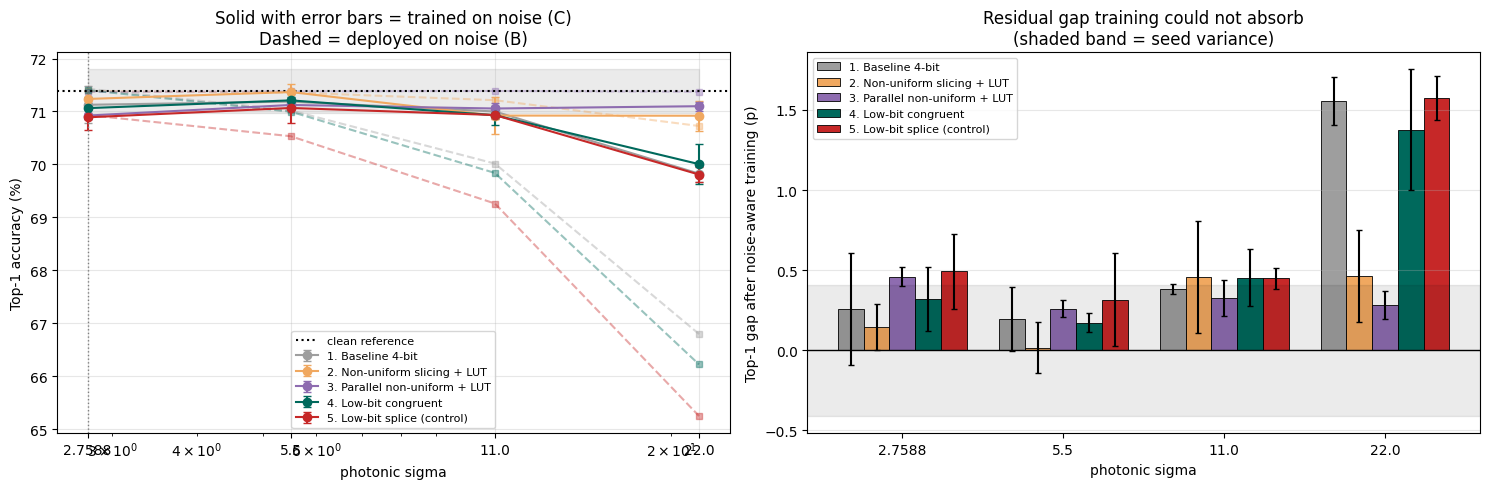

In [10]:
import matplotlib.pyplot as plt
COL = {"base": "#9e9e9e", "nonuni": "#f0a860", "parallel": "#8e6cb0",
       "lowbit_cong": "#00695c", "lowbit_splice": "#c62828"}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
for s in SCHEMES:
    cm = [get("trainC", sg, s)[0] for sg in SIGMAS]
    cs = [get("trainC", sg, s)[1] for sg in SIGMAS]
    bm = [get("inferB", sg, s)[0] for sg in SIGMAS]
    ax.errorbar(SIGMAS, cm, yerr=cs, fmt="o-", color=COL[s], ms=6,
                capsize=3, label=LABEL[s])
    ax.plot(SIGMAS, bm, "s--", color=COL[s], ms=4, alpha=0.4)
ax.axhline(ref_m, color="black", ls=":", lw=1.5, label="clean reference")
ax.fill_between([min(SIGMAS), max(SIGMAS)], ref_m - 2*ref_s, ref_m + 2*ref_s,
                color="black", alpha=0.08)
ax.axvline(2.7588, color="grey", ls=":", lw=1)
ax.set_xscale("log"); ax.set_xticks(SIGMAS)
ax.set_xticklabels([str(s) for s in SIGMAS])
ax.set_xlabel("photonic sigma"); ax.set_ylabel("Top-1 accuracy (%)")
ax.set_title("Solid with error bars = trained on noise (C)\nDashed = deployed on noise (B)")
ax.grid(alpha=0.3); ax.legend(fontsize=8)

ax = axes[1]
x = np.arange(len(SIGMAS)); w = 0.8 / len(SCHEMES)
for k, s in enumerate(SCHEMES):
    g = [ref_m - get("trainC", sg, s)[0] for sg in SIGMAS]
    e = [get("trainC", sg, s)[1] for sg in SIGMAS]
    ax.bar(x + (k - (len(SCHEMES)-1)/2) * w, g, w, yerr=e, capsize=2,
           color=COL[s], edgecolor="black", lw=0.6, label=LABEL[s])
ax.axhline(0, color="black", lw=1)
ax.axhspan(-2*ref_s, 2*ref_s, color="black", alpha=0.08)
ax.set_xticks(x); ax.set_xticklabels([str(s) for s in SIGMAS])
ax.set_xlabel("photonic sigma"); ax.set_ylabel("Top-1 gap after noise-aware training (p)")
ax.set_title("Residual gap after noise-aware training\n(shaded band = 2x clean-seed SD)")
ax.grid(axis="y", alpha=0.3); ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

In [11]:
print("=" * 96)
print("RESULT SUMMARY")
print("=" * 96)
print()
print("Clean reference: 71.38% Top-1 accuracy across three seeds.")
print("Practical resolution floor used for interpretation: 0.60 percentage points.")
print()
print("1. At sigma = 22, the uncorrected baseline loses 4.58 points under clean-trained noisy")
print("   inference. Noise-aware training recovers 3.03 points, leaving a 1.56-point gap.")
print()
print("2. Parallel MSB-corner correction is already close to the clean reference without")
print("   retraining. Across the four sigma values, noise-aware training changes its Top-1")
print("   accuracy by -0.45, -0.26, -0.33 and -0.27 points relative to Curve B.")
print("   All four changes lie inside the 0.60-point practical resolution floor.")
print()
print("3. The experiment therefore does not resolve an improvement from combining noise-aware")
print("   training with parallel corner correction. It also does not resolve a meaningful")
print("   degradation from doing so.")
print()
print("4. Noise-aware training can partially recover degradation in the uncorrected and")
print("   low-bit cases at higher noise, but it does not provide the same deployment-time")
print("   robustness as exact MSB-corner correction.")
print()
print("5. The splice case is retained only as a control demonstrating the failed low-bit")
print("   overwrite rule. It is not a proposed final correction scheme.")
print()
print("This experiment retrains network weights from scratch. The same approach cannot be")
print("applied unchanged where deployed weights must remain fixed.")
print("=" * 96)


RESULT SUMMARY

Clean reference: 71.38% Top-1 accuracy across three seeds.
Practical resolution floor used for interpretation: 0.60 percentage points.

1. At sigma = 22, the uncorrected baseline loses 4.58 points under clean-trained noisy
   inference. Noise-aware training recovers 3.03 points, leaving a 1.56-point gap.

2. Parallel MSB-corner correction is already close to the clean reference without
   retraining. Across the four sigma values, noise-aware training changes its Top-1
   accuracy by -0.45, -0.26, -0.33 and -0.27 points relative to Curve B.
   All four changes lie inside the 0.60-point practical resolution floor.

3. The experiment therefore does not resolve an improvement from combining noise-aware
   training with parallel corner correction. It also does not resolve a meaningful
   degradation from doing so.

4. Noise-aware training can partially recover degradation in the uncorrected and
   low-bit cases at higher noise, but it does not provide the same deployment-tim